# CS503 - Data Visualization - Project

**Comparative study of dimensionality-reduction techniques and their impact on regression**

Bishop's University - Department of Computer Science

The diabetes dataset has 442 patients, ten baseline input variables and a quantitative target `Y`
(disease progression one year after baseline). Below, each task is in its own code cell with a
heading that gives the task number.

### Setup - import libraries and define a few helpers used across the tasks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

import warnings
warnings.filterwarnings("ignore")   # hide cosmetic sklearn / umap warnings

%matplotlib inline
sns.set_style("whitegrid")
RANDOM_STATE = 42


def regression_views(emb, target, name):
    """Linear regression on the 1st dim and on the 1st+2nd dims of an embedding.

    Draws three panels (embedding scatter coloured by Y, the 1-D fit, the 2-D fit plane)
    and returns (mse_1d, mse_2d).
    """
    d1 = emb[:, [0]]
    d12 = emb[:, :2]

    lr1 = LinearRegression().fit(d1, target)
    mse1 = mean_squared_error(target, lr1.predict(d1))

    lr2 = LinearRegression().fit(d12, target)
    mse2 = mean_squared_error(target, lr2.predict(d12))

    df = pd.DataFrame(d12, columns=[f"{name}1", f"{name}2"])

    fig = plt.figure(figsize=(19, 5))

    ax1 = fig.add_subplot(1, 3, 1)
    sc = ax1.scatter(df.iloc[:, 0], df.iloc[:, 1], c=target, cmap="viridis", s=20)
    fig.colorbar(sc, ax=ax1, label="Y")
    ax1.set_xlabel(f"{name}1"); ax1.set_ylabel(f"{name}2")
    ax1.set_title(f"{name} scatter (colour = Y)")

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.scatter(df.iloc[:, 0], target, s=20, alpha=0.6, color="#1f77b4")
    xs = np.linspace(df.iloc[:, 0].min(), df.iloc[:, 0].max(), 100)
    ax2.plot(xs, lr1.predict(xs.reshape(-1, 1)), color="red", lw=2)
    ax2.set_xlabel(f"{name}1"); ax2.set_ylabel("Y")
    ax2.set_title(f"LR on {name}1  (MSE = {mse1:.2f})")

    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    ax3.scatter(df.iloc[:, 0], df.iloc[:, 1], target, s=12, color="#1f77b4", alpha=0.5)
    g1, g2 = np.meshgrid(np.linspace(df.iloc[:, 0].min(), df.iloc[:, 0].max(), 12),
                         np.linspace(df.iloc[:, 1].min(), df.iloc[:, 1].max(), 12))
    zz = lr2.intercept_ + lr2.coef_[0] * g1 + lr2.coef_[1] * g2
    ax3.plot_surface(g1, g2, zz, alpha=0.3, color="red")
    ax3.set_xlabel(f"{name}1"); ax3.set_ylabel(f"{name}2"); ax3.set_zlabel("Y")
    ax3.set_title(f"LR on {name}1+{name}2  (MSE = {mse2:.2f})")

    plt.tight_layout(); plt.show()
    return mse1, mse2


def mse_bar(mse1, mse2, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(["1 dimension", "2 dimensions"], [mse1, mse2],
                  color=["#8FBC9B", "#4472C4"])
    ax.bar_label(bars, fmt="%.2f")
    ax.set_ylabel("MSE"); ax.set_title(title)
    plt.tight_layout(); plt.show()

## Question 1 - Load the dataset

In [2]:
diabetes_df = pd.read_csv("diabetes2.csv")
print("Shape:", diabetes_df.shape)
diabetes_df.head()

Shape: (442, 11)


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


## Question 2 - Preprocessing: scale every variable to [0, 1] with MinMaxScaler

In [3]:
scaler = MinMaxScaler()
diabetes_df_s = pd.DataFrame(scaler.fit_transform(diabetes_df), columns=diabetes_df.columns)
diabetes_df_s.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,0.666667,1.0,0.582645,0.549296,0.294118,0.256972,0.207792,0.282087,0.562217,0.439394,0.392523
1,0.483333,0.0,0.148760,0.352113,0.421569,0.306773,0.623377,0.141044,0.222437,0.166667,0.155763
2,0.883333,1.0,0.516529,0.436620,0.289216,0.258964,0.246753,0.282087,0.496578,0.409091,0.361371
3,0.083333,0.0,0.301653,0.309859,0.495098,0.447211,0.233766,0.423131,0.572923,0.469697,0.563863
4,0.516667,0.0,0.206612,0.549296,0.465686,0.417331,0.389610,0.282087,0.362385,0.333333,0.342679


## Question 3 - Variance of each input variable

In [4]:
input_cols = [c for c in diabetes_df_s.columns if c != "Y"]
variances = diabetes_df_s[input_cols].var().sort_values(ascending=False)
print(variances)

SEX    0.249561
AGE    0.047735
BP     0.037950
S5     0.033623
BMI    0.033331
S4     0.033128
S6     0.030341
S1     0.028780
S3     0.028216
S2     0.022940
dtype: float64


## Question 4 - Bar chart of the input-variable variances

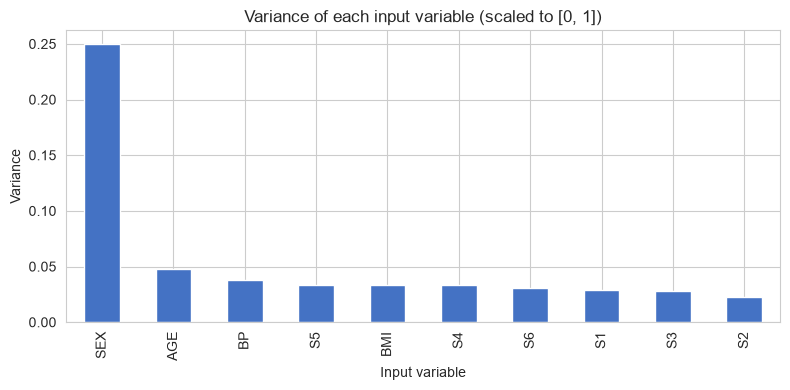

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
variances.plot(kind="bar", color="#4472C4", ax=ax)
ax.set_title("Variance of each input variable (scaled to [0, 1])")
ax.set_ylabel("Variance"); ax.set_xlabel("Input variable")
plt.tight_layout(); plt.show()

## Question 5 - Heatmap of pairwise correlation between all variables

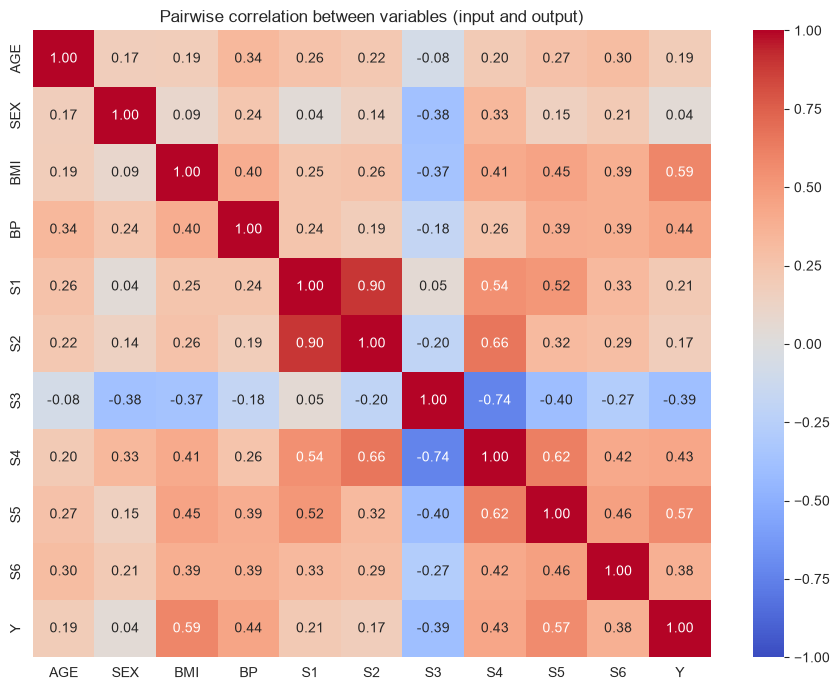

In [6]:
corr = diabetes_df_s.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pairwise correlation between variables (input and output)")
plt.tight_layout(); plt.show()

## Question 6 - Rank the input variables by their correlation with the output `Y`

In [7]:
corr_with_y = diabetes_df_s[input_cols].corrwith(diabetes_df_s["Y"])
ranking = corr_with_y.abs().sort_values(ascending=False)
print("Correlation with Y (absolute value, descending):")
for var in ranking.index:
    print(f"  {var:5s}  corr = {corr_with_y[var]:+.3f}")

Correlation with Y (absolute value, descending):
  BMI    corr = +0.586
  S5     corr = +0.566
  BP     corr = +0.441
  S4     corr = +0.430
  S3     corr = -0.395
  S6     corr = +0.382
  S1     corr = +0.212
  AGE    corr = +0.188
  S2     corr = +0.174
  SEX    corr = +0.043


## Question 7 - Scatter of the two most important input variables

Two most important inputs: ['BMI', 'S5']


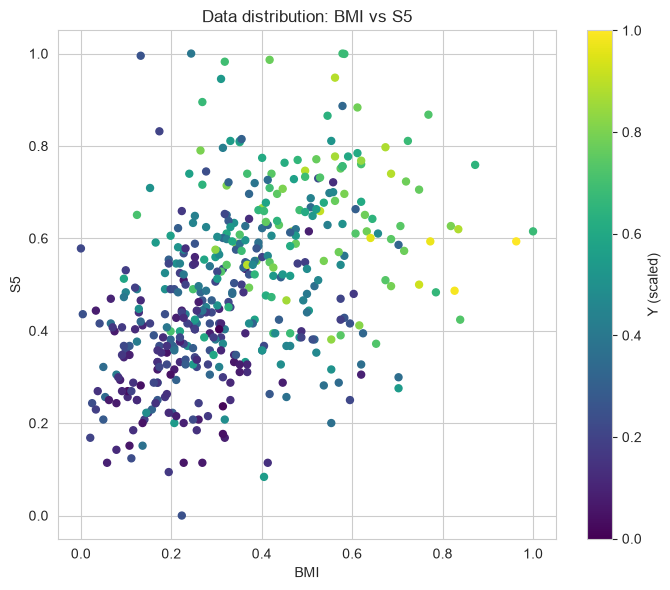

In [8]:
top2 = ranking.index[:2].tolist()
print("Two most important inputs:", top2)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(diabetes_df_s[top2[0]], diabetes_df_s[top2[1]],
                c=diabetes_df_s["Y"], cmap="viridis", s=25)
fig.colorbar(sc, ax=ax, label="Y (scaled)")
ax.set_xlabel(top2[0]); ax.set_ylabel(top2[1])
ax.set_title(f"Data distribution: {top2[0]} vs {top2[1]}")
plt.tight_layout(); plt.show()

## Question 8 - Lasso regression over the whole dataset

Inputs are the MinMax-scaled variables; the target is the original `Y` so that the regularisation
sweep over `alpha` (0 to 1000) is meaningful. For each alpha I record the MSE and the fitted
coefficients (alpha = 0 is plain linear regression). Parts a-f are all in this single cell.

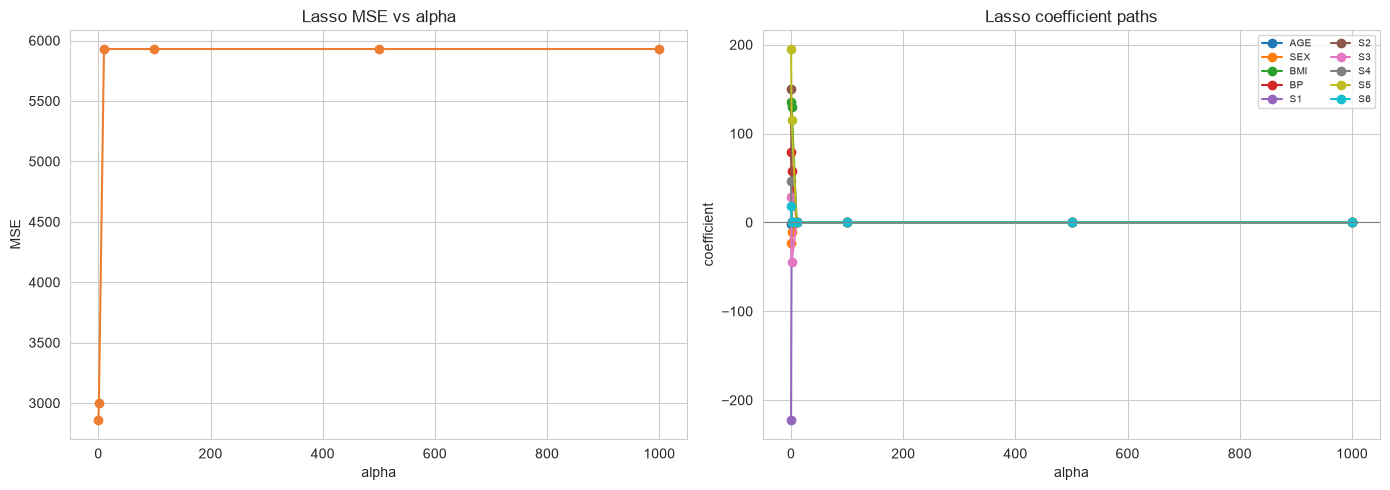

MSE for each alpha:
  alpha =     0:  MSE = 2859.696
  alpha =     1:  MSE = 3000.398
  alpha =    10:  MSE = 5929.885
  alpha =   100:  MSE = 5929.885
  alpha =   500:  MSE = 5929.885
  alpha =  1000:  MSE = 5929.885

Best MSE = 2859.696 at alpha = 0


In [9]:
X = diabetes_df_s[input_cols].values      # scaled inputs
y = diabetes_df["Y"].values               # original target

alphas = [0, 1, 10, 100, 500, 1000]
mse_by_alpha, coef_by_alpha = [], []
for a in alphas:
    model = LinearRegression() if a == 0 else Lasso(alpha=a, max_iter=100000)
    model.fit(X, y)
    mse_by_alpha.append(mean_squared_error(y, model.predict(X)))
    coef_by_alpha.append(model.coef_)
coef_by_alpha = np.array(coef_by_alpha)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(alphas, mse_by_alpha, marker="o", color="#ED7D31")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("MSE")
axes[0].set_title("Lasso MSE vs alpha")
for i, col in enumerate(input_cols):
    axes[1].plot(alphas, coef_by_alpha[:, i], marker="o", label=col)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("coefficient")
axes[1].set_title("Lasso coefficient paths")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

best = int(np.argmin(mse_by_alpha))
print("MSE for each alpha:")
for a, m in zip(alphas, mse_by_alpha):
    print(f"  alpha = {a:>5}:  MSE = {m:.3f}")
print(f"\nBest MSE = {mse_by_alpha[best]:.3f} at alpha = {alphas[best]}")

## Question 9 - PCA, then linear regression on the principal components

Parts a-g: scatter of PC1/PC2 coloured by Y, the loadings, linear regression on PC1 alone and on
PC1+PC2 with their fitted lines/plane, and a bar chart of the two MSEs.

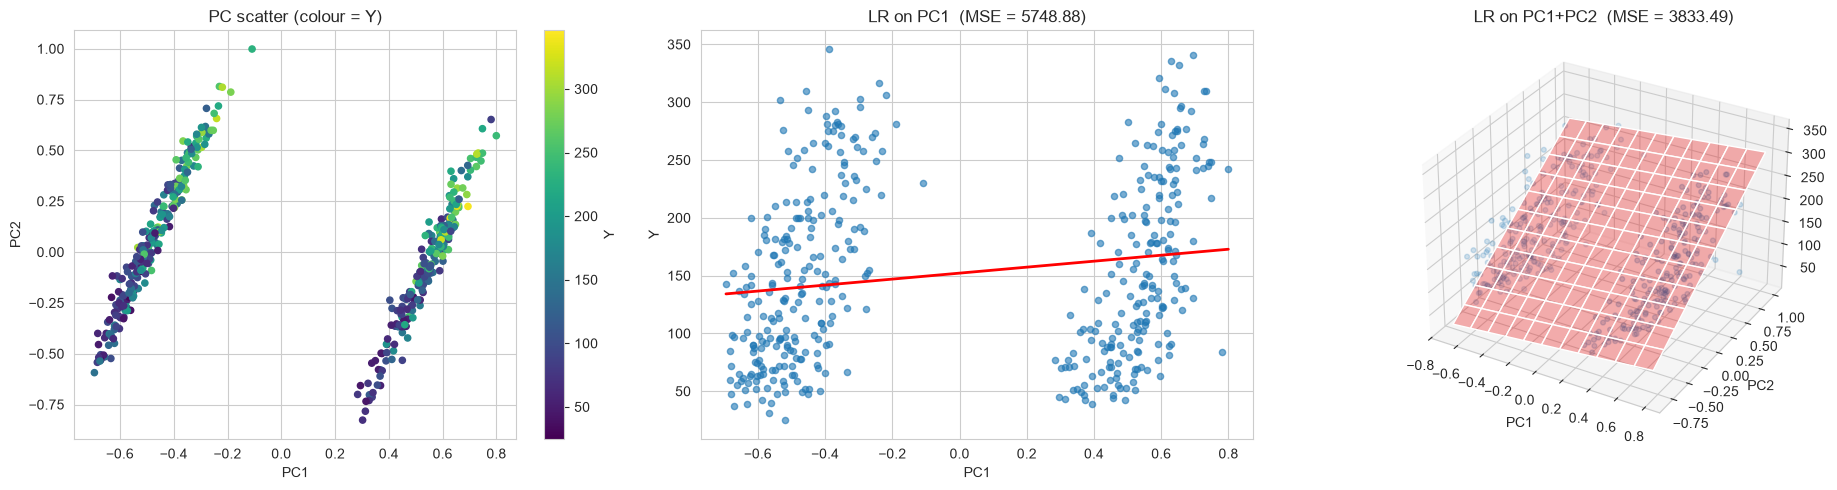

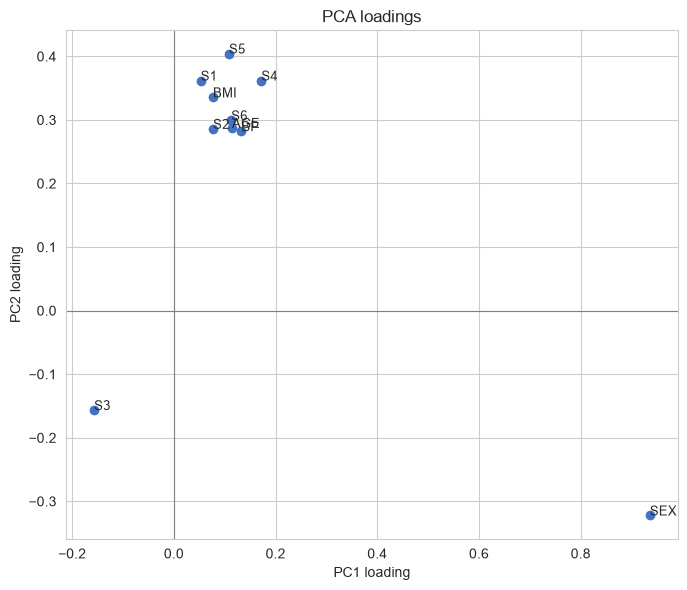

Explained variance ratio (PC1, PC2): [0.4977 0.1968]


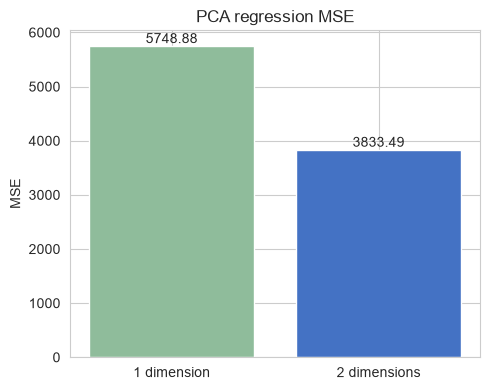

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

mse_pca_1, mse_pca_2 = regression_views(X_pca, y, "PC")

loadings = pd.DataFrame(pca.components_.T, index=input_cols, columns=["PC1", "PC2"])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(loadings["PC1"], loadings["PC2"], color="#4472C4")
for name, row in loadings.iterrows():
    ax.annotate(name, (row["PC1"], row["PC2"]), fontsize=9)
ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("PC1 loading"); ax.set_ylabel("PC2 loading")
ax.set_title("PCA loadings")
plt.tight_layout(); plt.show()

print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4))
mse_bar(mse_pca_1, mse_pca_2, "PCA regression MSE")

## Question 10 - t-SNE, then linear regression on the t-SNE dimensions

Part a shows the scatter for perplexity values 5, 10, 20 and 50. The regression (parts b-f) uses a
single embedding with perplexity 30.

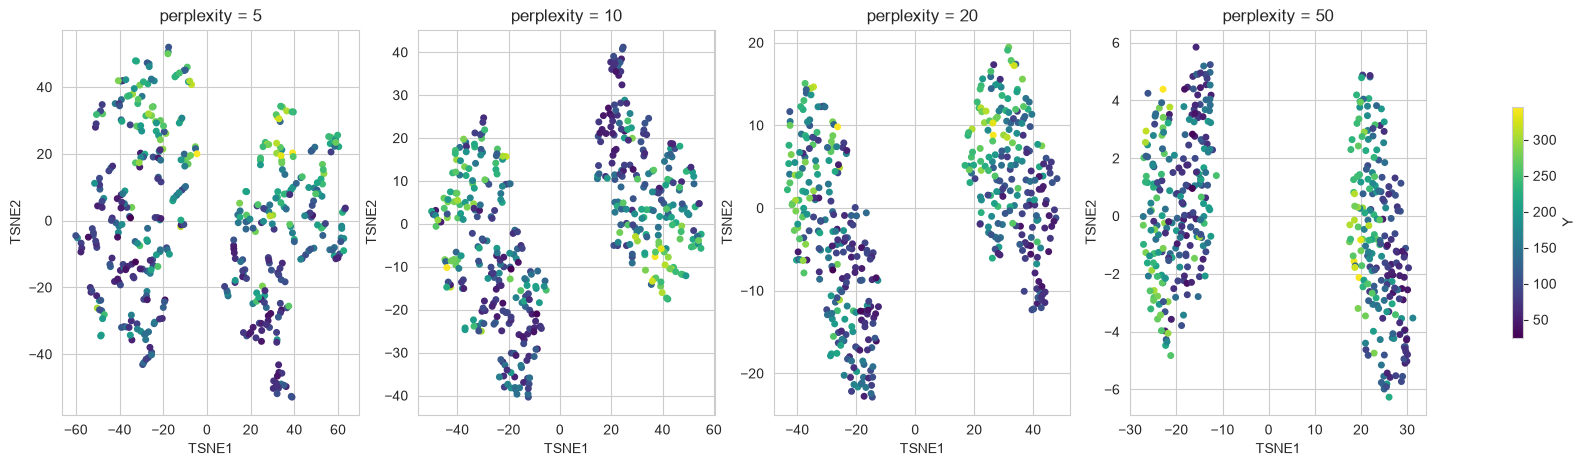

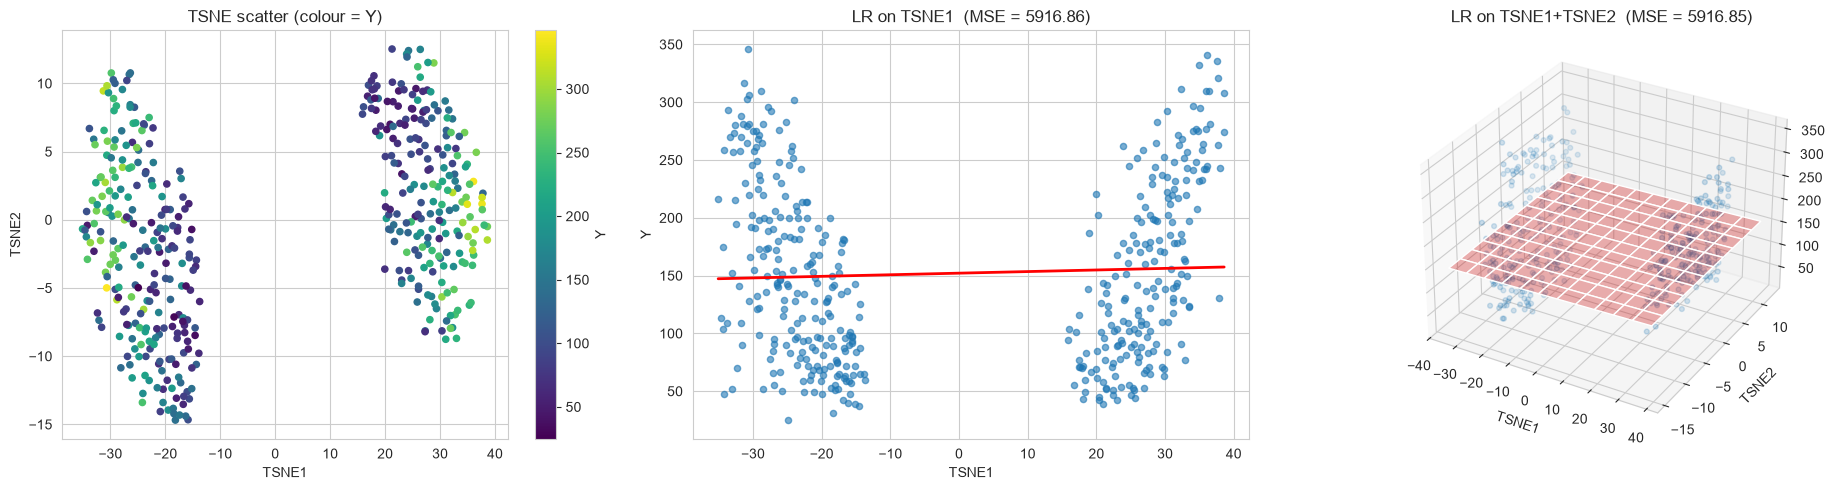

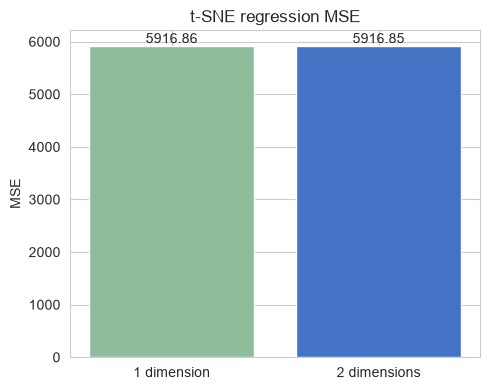

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, p in zip(axes, [5, 10, 20, 50]):
    emb = TSNE(n_components=2, perplexity=p, init="pca",
               learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="viridis", s=16)
    ax.set_title(f"perplexity = {p}")
    ax.set_xlabel("TSNE1"); ax.set_ylabel("TSNE2")
fig.colorbar(sc, ax=axes, label="Y", shrink=0.6)
plt.show()

X_tsne = TSNE(n_components=2, perplexity=30, init="pca",
              learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X)
mse_tsne_1, mse_tsne_2 = regression_views(X_tsne, y, "TSNE")
mse_bar(mse_tsne_1, mse_tsne_2, "t-SNE regression MSE")

## Question 11 - UMAP, then linear regression on the UMAP dimensions

Part a shows the scatter for n_neighbors values 5, 10, 20 and 50; parts b-f use a single embedding
(n_neighbors = 15). Part g compares linear regression on the first three dimensions of each
reduction method.

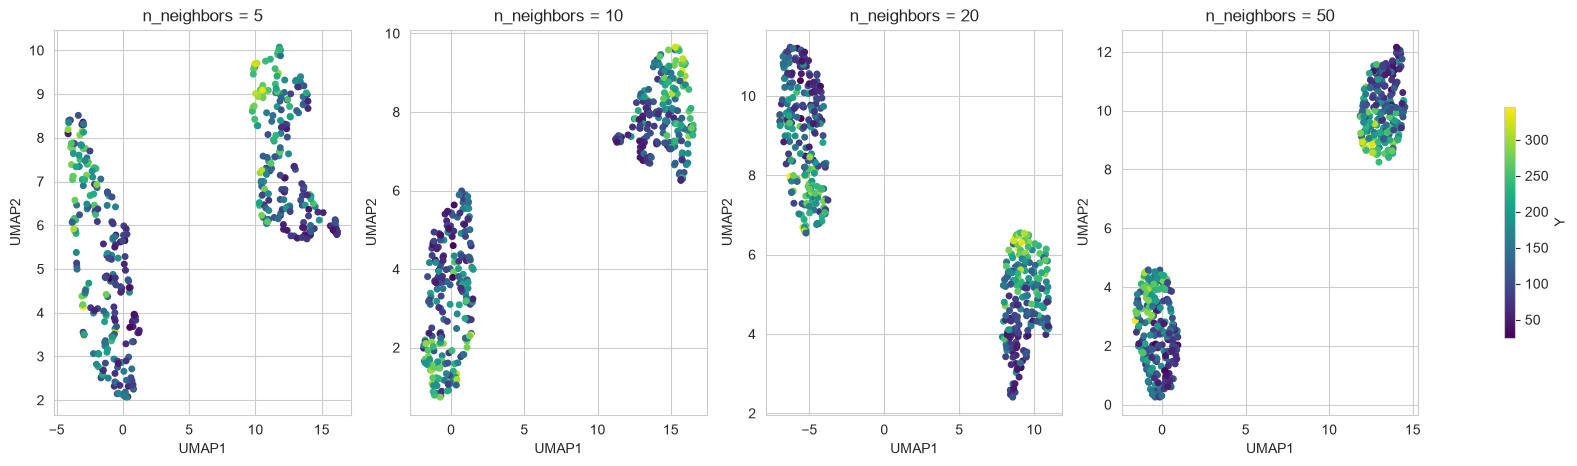

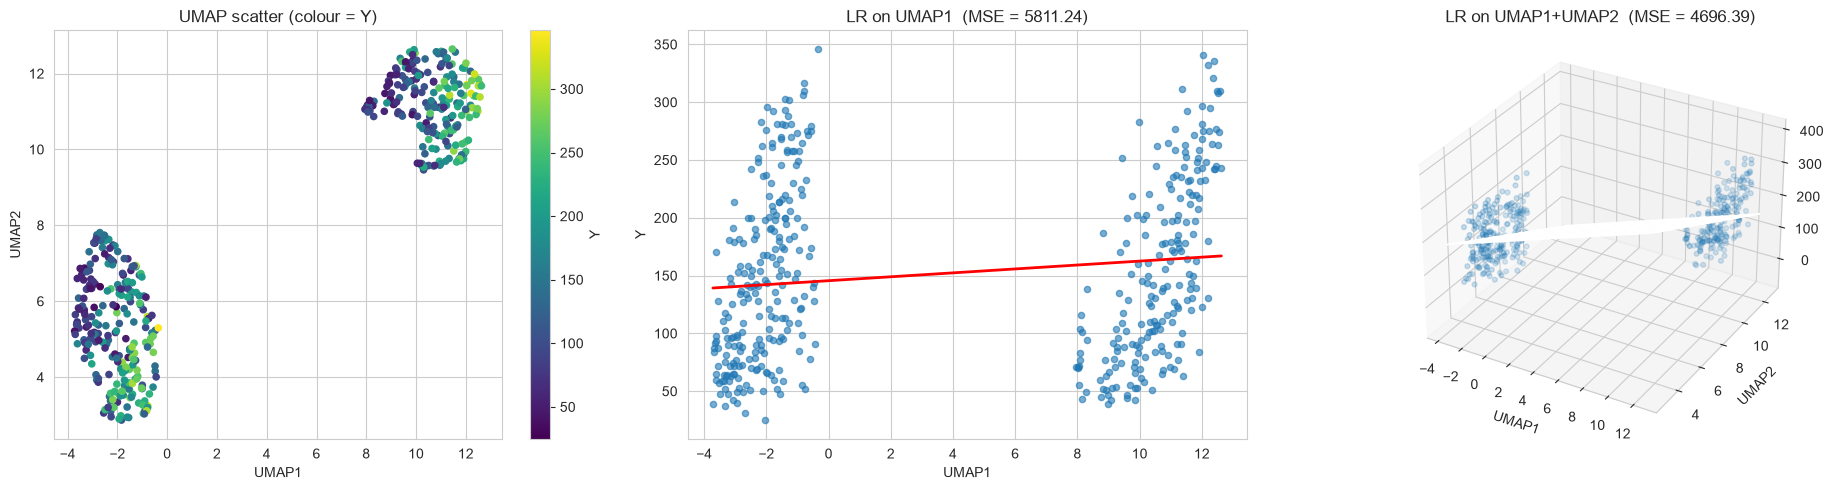

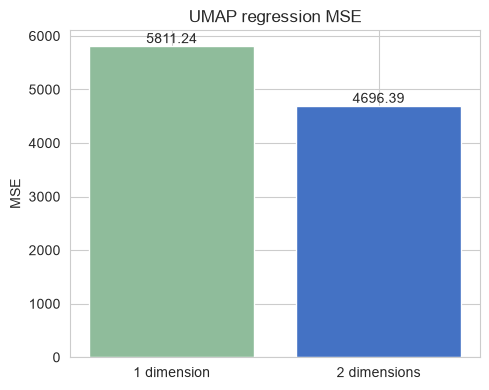

Linear regression on the first three dimensions of each method:
Method  MSE (3 dims)  R2 (3 dims)
   PCA       3804.51        0.358
 t-SNE       3450.11        0.418
  UMAP       4684.89        0.210

Overall MSE summary:
Method  MSE (1 dim)  MSE (2 dims)  MSE (3 dims)
   PCA      5748.88       3833.49       3804.51
 t-SNE      5916.86       5916.85       3450.11
  UMAP      5811.24       4696.39       4684.89


,Method,MSE (3 dims),R2 (3 dims)
0,PCA,3804.51,0.358
1,t-SNE,3450.11,0.418
2,UMAP,4684.89,0.210


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, nn in zip(axes, [5, 10, 20, 50]):
    emb = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                    random_state=RANDOM_STATE).fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="viridis", s=16)
    ax.set_title(f"n_neighbors = {nn}")
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
fig.colorbar(sc, ax=axes, label="Y", shrink=0.6)
plt.show()

X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                   random_state=RANDOM_STATE).fit_transform(X)
mse_umap_1, mse_umap_2 = regression_views(X_umap, y, "UMAP")
mse_bar(mse_umap_1, mse_umap_2, "UMAP regression MSE")

# (g) comparative table - linear regression on the first three dimensions of each method
pca3 = PCA(n_components=3, random_state=RANDOM_STATE).fit_transform(X)
tsne3 = TSNE(n_components=3, perplexity=30, init="pca",
             learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X)
umap3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                  random_state=RANDOM_STATE).fit_transform(X)

rows = []
for nm, e in [("PCA", pca3), ("t-SNE", tsne3), ("UMAP", umap3)]:
    lr = LinearRegression().fit(e, y)
    rows.append({"Method": nm,
                 "MSE (3 dims)": round(mean_squared_error(y, lr.predict(e)), 2),
                 "R2 (3 dims)": round(lr.score(e, y), 3)})
comparison = pd.DataFrame(rows)
print("Linear regression on the first three dimensions of each method:")
print(comparison.to_string(index=False))

# keep a tidy summary of every regression MSE for the write-up
summary = pd.DataFrame({
    "Method": ["PCA", "t-SNE", "UMAP"],
    "MSE (1 dim)": [round(mse_pca_1, 2), round(mse_tsne_1, 2), round(mse_umap_1, 2)],
    "MSE (2 dims)": [round(mse_pca_2, 2), round(mse_tsne_2, 2), round(mse_umap_2, 2)],
    "MSE (3 dims)": comparison["MSE (3 dims)"].tolist(),
})
print("\nOverall MSE summary:")
print(summary.to_string(index=False))
comparison